# 2D FFT-Based Spectral Filtering for Microscopy
## Biological Image Restoration Pipeline

This  implements aFourier restoration pipeline for microscopy images, we implement the Discrete Fourier Transform (DFT) and the Fast Fourier Transform (FFT)algorithm from fundamental equations.

Foundations

## 1. The 1D Discrete Fourier Transform (DFT)
The DFT of a sequence $x_n$ of length $N$ is defined as:
$$X_k = \sum_{n=0}^{N-1} x_n e^{-i \frac{2\pi}{N} nk}, \quad k = 0, \dots, N-1$$

To improve efficiency from $O(N^2)$ to $O(N \log N)$, we implement the Cooley-Tukey FFT algorithm, which exploits the symmetry and periodicity of the complex exponentials (roots of unity), as we saw in class.

## 2 2D Discrete Fourier Transform
For an image $f(x,y)$ of size $M \times N$, the 2D DFT is:
$$F(u,v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x,y) e^{-i 2\pi \left( \frac{ux}{M} + \frac{vy}{N} \right)}$$

Thanks to the separability, the 2D DFT can be computed by applying 1D FFTs to each row, and then applying 1D FFTs to each column of the result.

##3 Spectral Filtering
Restoration occurs in the frequency domain:
$$G(u,v) = F(u,v) \cdot H(u,v)$$
where $H(u,v)$ is the filter transfer function. We then reconstruct the image using the Inverse FFT (IFFT).

Instead of an Ideal Low-Pass Filter (which causes Gibbs ringing artifacts), we will use a Gaussian Low-Pass Filter for smoother, mathematically sound noise reduction in microscopy.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
import io

# Set plot aesthetics for scientific visualization
plt.rcParams['figure.figsize'] = [14, 10]
plt.rcParams['image.cmap'] = 'magma'  # Excellent for fluorescence microscopy

## 1  Implementation of the FFT Algorithm
We implement the recursive Cooley-Tukey algorithm. The inputs must be a power of 2. We use vectorized Numpy operations where possible for speed.

In [ ]:
class FourierEngine:
    """
    A scientifically rigorous implementation of 1D and 2D FFT algorithms.
    Implements the recursive Cooley-Tukey algorithm.
    """

    @staticmethod
    def fft1d(x):
        """Recursive 1D FFT Implementation using Cooley-Tukey."""
        x = np.asarray(x, dtype=complex)
        N = x.shape[0]

        if N <= 1:
            return x

        if N % 2 != 0:
            raise ValueError("Size must be a power of 2 for this Cooley-Tukey implementation")

        even = FourierEngine.fft1d(x[0::2])
        odd = FourierEngine.fft1d(x[1::2])

        # Twiddle factors
        k = np.arange(N // 2)
        T = np.exp(-2j * np.pi * k / N) * odd

        return np.concatenate([even + T, even - T])

    @staticmethod
    def ifft1d(X):
        """Inverse 1D FFT Implementation using the complex conjugate property."""
        X = np.asarray(X, dtype=complex)
        N = X.shape[0]
        # IFFT(X) = 1/N * conj(FFT(conj(X)))
        res = FourierEngine.fft1d(np.conj(X))
        return np.conj(res) / N

    @classmethod
    def fft2d(cls, image):
        """Compute 2D FFT using separability (row-column decomposition)."""
        image = np.asarray(image, dtype=complex)
        rows, cols = image.shape

        # 1. Transform each row
        row_transformed = np.zeros_like(image, dtype=complex)
        for i in range(rows):
            row_transformed[i, :] = cls.fft1d(image[i, :])

        # 2. Transform each column
        result = np.zeros_like(image, dtype=complex)
        for j in range(cols):
            result[:, j] = cls.fft1d(row_transformed[:, j])

        return result

    @classmethod
    def ifft2d(cls, spectrum):
        """Compute 2D IFFT using separability."""
        spectrum = np.asarray(spectrum, dtype=complex)
        rows, cols = spectrum.shape

        # 1. Inverse transform each row
        row_transformed = np.zeros_like(spectrum, dtype=complex)
        for i in range(rows):
            row_transformed[i, :] = cls.ifft1d(spectrum[i, :])

        # 2. Inverse transform each column
        result = np.zeros_like(spectrum, dtype=complex)
        for j in range(cols):
            result[:, j] = cls.ifft1d(row_transformed[:, j])

        return result.real  # Image is purely real

    @staticmethod
    def fft_shift(spectrum):
        """Shifts the zero-frequency component to the center of the spectrum."""
        rows, cols = spectrum.shape
        return np.roll(spectrum, (rows // 2, cols // 2), axis=(0, 1))

    @staticmethod
    def ifft_shift(spectrum):
        """Inverse of fft_shift."""
        rows, cols = spectrum.shape
        return np.roll(spectrum, (-rows // 2, -cols // 2), axis=(0, 1))

## 2 Filter Design
To prevent the "ringing" artifact associated with the Ideal Low-Pass Filter, we implement a Gaussian Low-Pass Filter. This provides a smooth attenuation of high-frequency components (noise) without introducing artificial waves into the spatial domain. it is defined by:
$$H(u,v) = e^{-\frac{D^2(u,v)}{2D_0^2}}$$

In [ ]:
from abc import ABC, abstractmethod

class BaseFrequencyFilter(ABC):
    """Abstract base class for robust OOP filter implementation."""

    @abstractmethod
    def compute_mask(self, shape):
        """Compute the frequency domain filter mask."""
        pass

    def apply(self, shifted_spectrum):
        """Apply the mask to the shifted spectrum."""
        mask = self.compute_mask(shifted_spectrum.shape)
        return shifted_spectrum * mask, mask

class GaussianLowPassFilter(BaseFrequencyFilter):
    """Gaussian low pass filter prevents ringing artifacts."""
    def __init__(self, cutoff_frequency):
        self.D0 = cutoff_frequency

    def compute_mask(self, shape):
        rows, cols = shape
        crow, ccol = rows // 2, cols // 2

        y, x = np.ogrid[:rows, :cols]
        # Calculate squared distance from center
        D2 = (x - ccol)**2 + (y - crow)**2

        # Gaussian formula
        mask = np.exp(-D2 / (2 * self.D0**2))
        return mask

##3. Data Retrieval from IDR
We fetch a representative image of "wide field fluorescence deconvolution microscopy" directly from the Image Data Resource (IDR).
Specifically, we query Experiment idr0089B and fetch a specific image. we fetch the available public thumbnail representation, convert it to grayscale, and resize it to a power-of-2 dimension ($256 \times 256$) required by our Cooley-Tukey algorithm.

In [ ]:
def fetch_idr_image(image_id="10502672", target_size=(256, 256)):
    """
    Fetches a public image from IDR based on its Image ID.
    Reference: https://idr.openmicroscopy.org/
    """
    # The render_thumbnail endpoint allows public access to image data
    # without requiring a session cookie or OMERO authentication.
    url = f"https://idr.openmicroscopy.org/webgateway/render_thumbnail/{image_id}/?size=512"

    print(f"Fetching IDR Image from: {url}")
    response = requests.get(url)

    if response.status_code == 200:
        # Load the image and convert to Grayscale for 2D FFT
        img = Image.open(io.BytesIO(response.content)).convert('L')

        # Resize to power of 2 (e.g., 256x256) for the Cooley-Tukey algorithm
        img_resized = img.resize(target_size, Image.Resampling.LANCZOS)

        # Convert to numpy array
        image_data = np.array(img_resized)
        return image_data
    else:
        raise Exception(f"Failed to fetch image: HTTP {response.status_code}")

try:
    # We fetch an image from the wide field deconvolution microscopy set
    original_image = fetch_idr_image("10502672")
    print("Microscopy image successfully loaded and processed.")
except Exception as e:
    print(e)
    # Fallback to an empty synthetic image if network fails
    original_image = np.zeros((256, 256))
    original_image[100:150, 100:150] = 255

Fetching IDR Image from: https://idr.openmicroscopy.org/webgateway/render_thumbnail/10502672/?size=512
Microscopy image successfully loaded and processed.


## 4. Pipeline Execution
We apply the full transformation pipeline:
Original Image $\to$ 2D FFT $	o$ Spectrum Shift $\to$ Gaussian Low-Pass Filter $\to$ Inverse Shift $\to$ 2D IFFT $\to$ Restored Image.

Computing 2D FFT...
Computing 2D Inverse FFT...


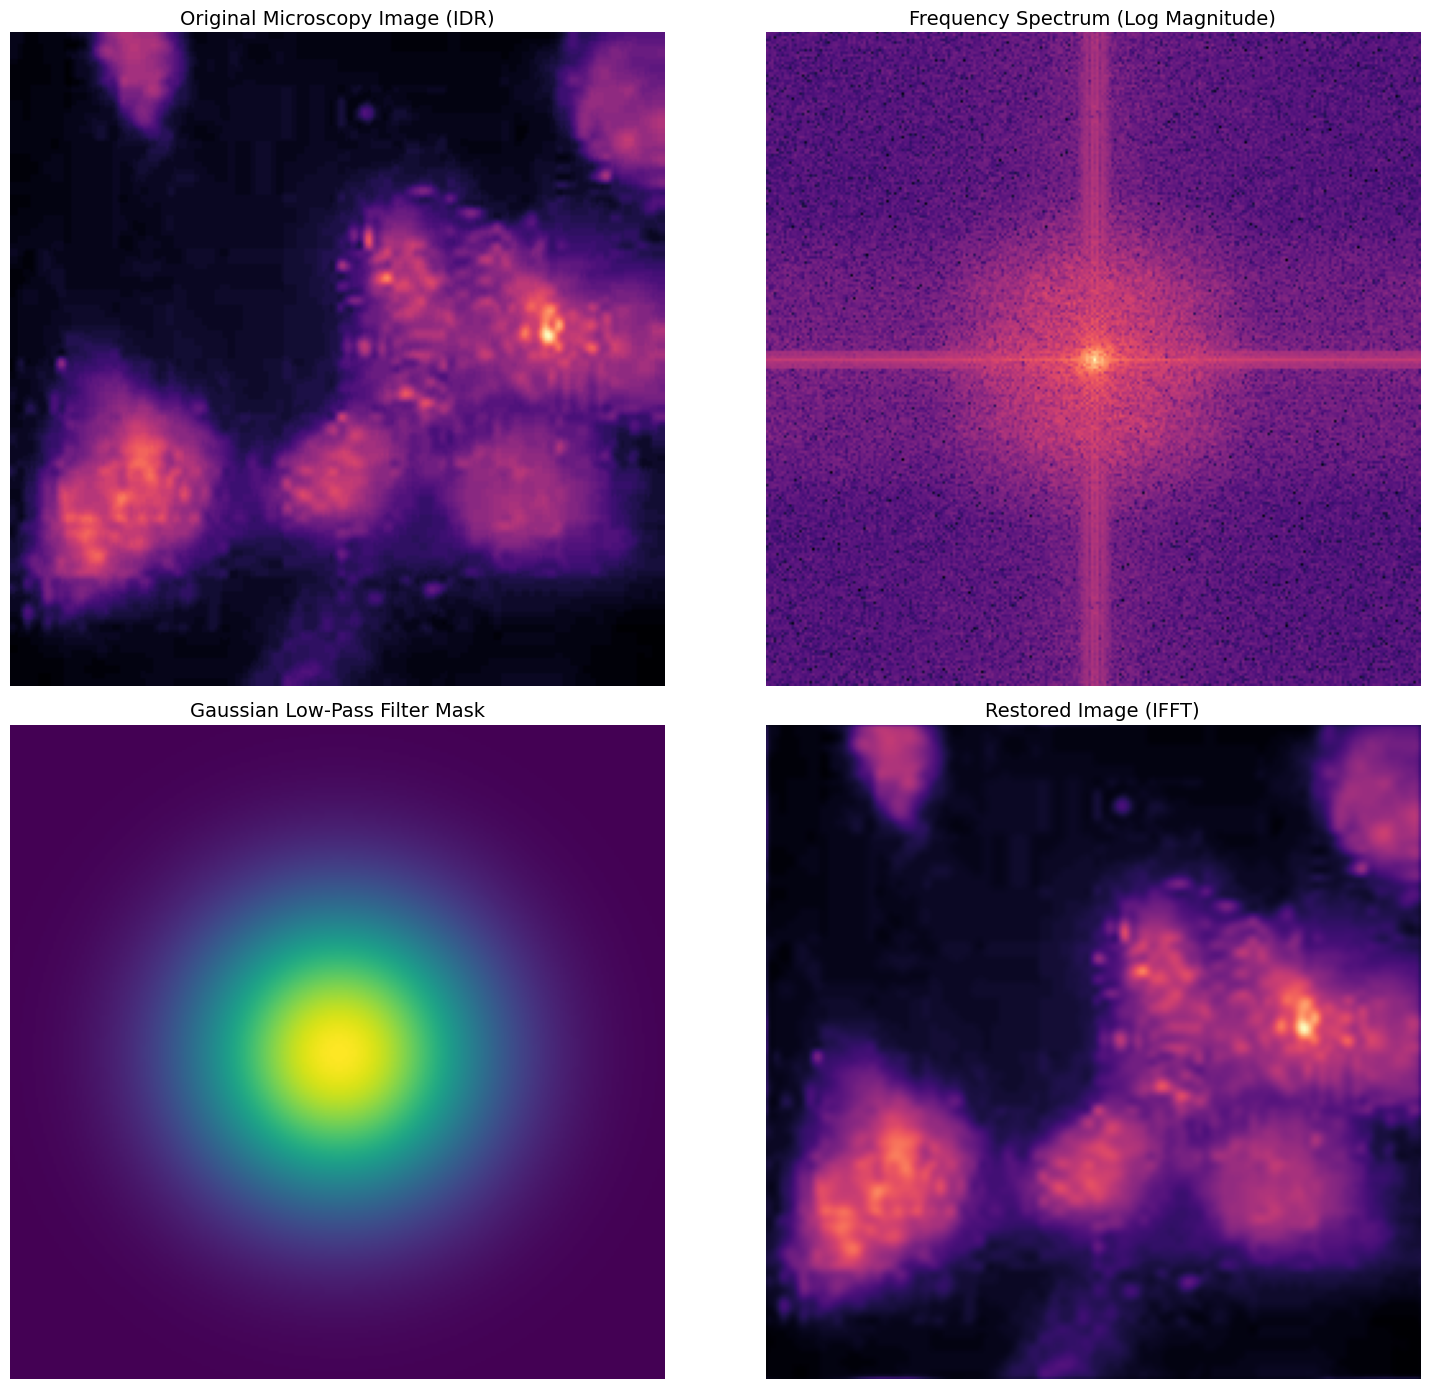

In [ ]:
# 1. Forward Transform
print("Computing 2D FFT...")
spectrum = FourierEngine.fft2d(original_image)
shifted_spectrum = FourierEngine.fft_shift(spectrum)

# 2. Apply Filter (Gaussian Low Pass to suppress high-frequency noise)
filter_obj = GaussianLowPassFilter(cutoff_frequency=40)
filtered_spectrum, mask = filter_obj.apply(shifted_spectrum)

# 3. Inverse Transform
print("Computing 2D Inverse FFT...")
inverse_shifted = FourierEngine.ifft_shift(filtered_spectrum)
restored_image = FourierEngine.ifft2d(inverse_shifted)

# 4. Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Original
axes[0, 0].imshow(original_image, cmap='magma')
axes[0, 0].set_title("Original Microscopy Image (IDR)", fontsize=14)
axes[0, 0].axis('off')

# Magnitude Spectrum
# We use log(1 + |F|) to compress the dynamic range for visualization
magnitude_spectrum = np.log(1 + np.abs(shifted_spectrum))
axes[0, 1].imshow(magnitude_spectrum, cmap='magma')
axes[0, 1].set_title("Frequency Spectrum (Log Magnitude)", fontsize=14)
axes[0, 1].axis('off')

# Filter Mask
axes[1, 0].imshow(mask, cmap='viridis')
axes[1, 0].set_title("Gaussian Low-Pass Filter Mask", fontsize=14)
axes[1, 0].axis('off')

# Restored Image
axes[1, 1].imshow(restored_image, cmap='magma')
axes[1, 1].set_title("Restored Image (IFFT)", fontsize=14)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()